# FAIR-TRACE / SCAFF on MovieLens-1M — a real per-stage reference

The toy notebook showed the machinery works. This one replaces the synthetic oracle with the
real thing: **MovieLens-1M**, one of the two datasets CFaiRLLM uses.

What changes, and what does not:

| | toy notebook | this notebook |
|---|---|---|
| reference \(\mathcal{G}_s\) | synthetic oracle, exact by construction | held-out consumption: test-split items the user rated \(\ge 4\) |
| user preferences | generated | inferred from the user's own training ratings |
| attributes | invented values | `sex` from `users.dat`; `age` bucketed from the real age code |
| catalog | 30 fake items | 3,883 real films with genres and release years |
| planted faults | present | still present — they remain the instrument's unit test |

Two things to be explicit about, because both are places where CFaiRLLM leaves a gap:

1. **The age mapping is stated here.** ML-1M ships seven age codes; CFaiRLLM's prompts use three
   buckets and the paper never says how the seven become three. This notebook declares the
   mapping in the config cell so the choice is auditable.
2. **The identity in the prompt is not the user's real identity.** Every sampled user is run
   under every attribute value, exactly as in a counterfactual audit. The real `users.dat`
   attribute is kept aside and used only in section 12, to ask a question CFaiRLLM cannot:
   does stating the user's *true* attribute help them more than stating a false one?

No API key and no LLM. The five stage functions are deterministic, so every number here is
reproducible and the run takes about a minute.

In [1]:
#@title 1. Configuration { display-mode: "form" }
SEED = 42 #@param {type:"integer"}
N_USERS = 150 #@param {type:"integer"}          # CFaiRLLM samples ~150 users per dataset
N_PROFILE = 10 #@param {type:"integer"}         # CFaiRLLM's N_prof
TOP_K = 10 #@param {type:"integer"}             # CFaiRLLM recommends 10 titles
N_REPEATS = 2 #@param {type:"integer"}
LIKE_THRESHOLD = 4 #@param {type:"integer"}     # a test item counts as "truly preferred" at >= this
TEST_FRACTION = 0.2 #@param {type:"number"}
DIRECT_EFFECT_MARGIN = 0.10 #@param {type:"number"}
STOCHASTICITY = 0.02 #@param {type:"number"}

SAMPLING_STRATEGIES = ["random", "top_rated", "recent"]
OUTPUT_DIR = "fair_trace_ml1m_outputs" #@param {type:"string"}

STAGES = ["Elicit", "Retrieve", "Rank", "Explain", "Memory"]
NEUTRAL = "unspecified"

# ML-1M ships seven age codes. CFaiRLLM's prompts use three buckets and never state the
# mapping; this is ours, declared so it can be argued with.
AGE_BUCKETS = {1: "teen", 18: "young", 25: "young", 35: "adult", 45: "adult", 50: "adult", 56: "adult"}

ATTRIBUTES = {
    "sex": ["man", "woman"],              # binary: SNSV collapses to SNSR/2
    "age": ["teen", "young", "adult"],    # ternary: SNSV becomes independent
}
SEX_FROM_CODE = {"M": "man", "F": "woman"}

# The stereotype the planted fault injects. Artificial, and a unit test of the instrument only.
BIAS_GENRE = {"woman": "Romance", "teen": "Children's", "man": "Action", "young": "Horror",
              "adult": "Drama"}

PRIMARY_METRIC = {"Elicit": "pref_jaccard", "Retrieve": "candidate_jaccard",
                  "Rank": "rbo_distance", "Explain": "reason_jaccard", "Memory": "fact_jaccard"}

print("Configuration loaded.")
print("age mapping:", AGE_BUCKETS)
print("attributes:", ATTRIBUTES)

Configuration loaded.
age mapping: {1: 'teen', 18: 'young', 25: 'young', 35: 'adult', 45: 'adult', 50: 'adult', 56: 'adult'}
attributes: {'sex': ['man', 'woman'], 'age': ['teen', 'young', 'adult']}


In [2]:
#@title 2. Imports
import os, json, math, hashlib, warnings, zipfile, urllib.request
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 100)
OUT = Path(OUTPUT_DIR); OUT.mkdir(parents=True, exist_ok=True)


def stable_int(*parts):
    return int(hashlib.sha256("||".join(map(str, parts)).encode()).hexdigest()[:8], 16)


def jaccard_distance(left, right):
    left, right = set(left or []), set(right or [])
    if not left and not right:
        return 0.0
    return 1.0 - len(left & right) / len(left | right)


def jaccard_similarity(left, right):
    return 1.0 - jaccard_distance(left, right)


def rbo_score(left, right, p=0.9):
    left, right = list(left or []), list(right or [])
    if not left and not right:
        return 1.0
    depth = max(len(left), len(right))
    seen_l, seen_r, score = set(), set(), 0.0
    for d in range(1, depth + 1):
        if d <= len(left):
            seen_l.add(left[d - 1])
        if d <= len(right):
            seen_r.add(right[d - 1])
        score += (1 - p) * (p ** (d - 1)) * (len(seen_l & seen_r) / d)
    score += (p ** depth) * (len(seen_l & seen_r) / depth)
    return float(score)


def ndcg_at_k(ranked, relevance, k):
    def dcg(items):
        return sum((2 ** max(relevance.get(i, 0), 0) - 1) / math.log2(pos + 2)
                   for pos, i in enumerate(items[:k]))
    ideal = sorted(relevance, key=relevance.get, reverse=True)[:k]
    denom = dcg(ideal)
    return dcg(ranked) / denom if denom > 0 else np.nan


def population_std(values):
    values = [v for v in values if v == v]
    if not values:
        return np.nan
    mu = sum(values) / len(values)
    return math.sqrt(sum((v - mu) ** 2 for v in values) / len(values))

print("Imports ready. Output:", OUT.resolve())

Imports ready. Output: /private/tmp/claude-501/-Users-jiarui-niw-github-fair-trace/0fe9f38e-f4de-48a4-8479-6c571e0e715d/scratchpad/ml1m_run/fair_trace_ml1m_outputs


In [3]:
#@title 3. Load MovieLens-1M
DATA = Path("ml-1m")
if not (DATA / "ratings.dat").exists():
    print("downloading ml-1m.zip (about 6 MB) from GroupLens ...")
    urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", "ml-1m.zip")
    with zipfile.ZipFile("ml-1m.zip") as z:
        z.extractall(".")
    print("done")

RATINGS = pd.read_csv(DATA / "ratings.dat", sep="::", engine="python", encoding="latin-1",
                      names=["user", "item", "rating", "ts"])
USERS = pd.read_csv(DATA / "users.dat", sep="::", engine="python", encoding="latin-1",
                    names=["user", "gender", "age_code", "occupation", "zip"])
MOVIES = pd.read_csv(DATA / "movies.dat", sep="::", engine="python", encoding="latin-1",
                     names=["item", "title", "genres"])
MOVIES["year"] = MOVIES["title"].str.extract(r"\((\d{4})\)$").astype(float)
MOVIES["genre_set"] = MOVIES["genres"].str.split("|").apply(set)

USERS["sex"] = USERS["gender"].map(SEX_FROM_CODE)
USERS["age"] = USERS["age_code"].map(AGE_BUCKETS)

print(f"{len(RATINGS):,} ratings · {len(USERS):,} users · {len(MOVIES):,} movies")
print("\nreal attribute distribution (this is the population, not the audit sample):")
display(pd.crosstab(USERS["sex"], USERS["age"]))

1,000,209 ratings · 6,040 users · 3,883 movies

real attribute distribution (this is the population, not the audit sample):


age,adult,teen,young
sex,,,
man,1844,144,2343
woman,775,78,856


## 4. The split, and what becomes the reference

Each user's ratings are ordered by timestamp. The first 80% builds the profile the agent sees;
the last 20% is held out. Within that held-out tail, the items rated 4 or 5 are the user's
**true preferences** \(T_u\) — the reference set, exactly CFaiRLLM's construction.

Nothing derived from \(T_u\) ever reaches the agent. It is read for the first time in the
consequence block, section 9.

In [4]:
#@title 4. Temporal split, reference sets, and a stratified user sample
R = RATINGS.sort_values(["user", "ts"]).copy()
R["pos"] = R.groupby("user").cumcount()
R["n"] = R.groupby("user")["item"].transform("size")
R["is_test"] = R["pos"] >= (R["n"] * (1 - TEST_FRACTION)).astype(int)

TRAIN = R[~R["is_test"]]
TEST = R[R["is_test"]]

# popularity comes from the training half only, so nothing leaks from the reference
POPULARITY = TRAIN.groupby("item").size().rename("pop")
MOVIES = MOVIES.merge(POPULARITY, on="item", how="left").fillna({"pop": 0})

n_train = TRAIN.groupby("user").size().rename("n_train")
liked_test = (TEST[TEST["rating"] >= LIKE_THRESHOLD].groupby("user").size().rename("n_liked"))
eligible = pd.concat([n_train, liked_test], axis=1).fillna(0)
eligible = eligible[(eligible["n_train"] >= N_PROFILE) & (eligible["n_liked"] >= 3)]
eligible = eligible.join(USERS.set_index("user")[["sex", "age"]])

# Stratify so every attribute value has support: the raw population is 4331 M vs 1709 F.
rng = np.random.default_rng(SEED)
cells = eligible.groupby(["sex", "age"]).size()
per_cell = max(1, N_USERS // len(cells))
picked = []
for (sex, age), group in eligible.groupby(["sex", "age"]):
    take = min(per_cell, len(group))
    picked.extend(rng.choice(group.index.values, size=take, replace=False).tolist())
remaining = [u for u in eligible.index if u not in set(picked)]
if len(picked) < N_USERS and remaining:
    picked.extend(rng.choice(remaining, size=min(N_USERS - len(picked), len(remaining)),
                             replace=False).tolist())
SAMPLE = sorted(picked)[:N_USERS]

REFERENCE = {u: set(TEST[(TEST["user"] == u) & (TEST["rating"] >= LIKE_THRESHOLD)]["item"])
             for u in SAMPLE}
TEST_RELEVANCE = {u: dict(zip(g["item"], g["rating"]))
                  for u, g in TEST[TEST["user"].isin(SAMPLE)].groupby("user")}

print(f"eligible users: {len(eligible):,}   sampled: {len(SAMPLE)}")
print("\naudit sample by real attribute:")
display(pd.crosstab(eligible.loc[SAMPLE, "sex"], eligible.loc[SAMPLE, "age"]))
print("reference size |T_u|:", pd.Series({u: len(v) for u, v in REFERENCE.items()}).describe().round(1).to_dict())

eligible users: 5,606   sampled: 150

audit sample by real attribute:


age,adult,teen,young
sex,,,
man,25,25,25
woman,25,25,25


reference size |T_u|: {'count': 150.0, 'mean': 17.2, 'std': 19.1, 'min': 3.0, '25%': 6.0, '50%': 11.0, '75%': 20.0, 'max': 143.0}


In [5]:
#@title 5. Derive each user's profile and latent preferences from the training half
MOVIE_BY_ID = MOVIES.set_index("item")


def era_of(year):
    if year != year:
        return "unknown"
    return "classic" if year < 1980 else ("modern" if year < 1995 else "recent")


MOVIES["era"] = MOVIES["year"].apply(era_of)
ERA_BY_ID = dict(zip(MOVIES["item"], MOVIES["era"]))
GENRES_BY_ID = dict(zip(MOVIES["item"], MOVIES["genre_set"]))


def build_user(u):
    hist = TRAIN[TRAIN["user"] == u].merge(MOVIES, on="item")
    liked = hist[hist["rating"] >= LIKE_THRESHOLD]
    source = liked if len(liked) >= N_PROFILE else hist

    genre_counts = pd.Series([g for s in source["genre_set"] for g in s]).value_counts()
    top_genres = genre_counts.head(2).index.tolist()
    era_counts = source["era"].value_counts()
    top_era = era_counts.index[0] if len(era_counts) else "unknown"

    truth = {"genre": top_genres[0] if top_genres else "Drama",
             "genre2": top_genres[1] if len(top_genres) > 1 else None,
             "era": top_era}
    # The user states one facet up front; the rest is what Elicit could usefully ask about.
    revealed = {"genre": truth["genre"]}
    unresolved = [k for k in ("genre2", "era") if truth.get(k)]

    profiles = {}
    for strategy in SAMPLING_STRATEGIES:
        if strategy == "random":
            pick = source.sample(n=min(N_PROFILE, len(source)), random_state=stable_int(SEED, u))
        elif strategy == "top_rated":
            pick = source.sort_values(["rating", "pop"], ascending=False).head(N_PROFILE)
        else:
            pick = source.sort_values("ts", ascending=False).head(N_PROFILE)
        profiles[strategy] = pick["item"].tolist()

    return {"user": u, "true_preferences": truth, "revealed_preferences": revealed,
            "unresolved_facets": unresolved, "profiles": profiles,
            "real_sex": USERS.set_index("user").loc[u, "sex"],
            "real_age": USERS.set_index("user").loc[u, "age"]}


USER_STATE = {u: build_user(u) for u in SAMPLE}
example = USER_STATE[SAMPLE[0]]
print("example user:", example["user"], "| real:", example["real_sex"], example["real_age"])
print("  inferred preferences:", example["true_preferences"])
print("  unresolved facets   :", example["unresolved_facets"])
print("  top-rated profile   :", [MOVIE_BY_ID.loc[i, "title"] for i in example["profiles"]["top_rated"][:4]])
print("  |reference T_u|     :", len(REFERENCE[example["user"]]))

example user: 48 | real: man young
  inferred preferences: {'genre': 'Drama', 'genre2': 'Action', 'era': 'modern'}
  unresolved facets   : ['genre2', 'era']
  top-rated profile   : ['Star Wars: Episode V - The Empire Strikes Back (1980)', 'Star Wars: Episode IV - A New Hope (1977)', 'Star Wars: Episode VI - Return of the Jedi (1983)', 'Saving Private Ryan (1998)']
  |reference T_u|     : 12


In [6]:
#@title 6. The five stage functions, now over the real catalog
def random_event(rng, p=STOCHASTICITY):
    return rng.random() < p


def planted_for(state, attribute_value):
    """The artificial stereotype this run injects, if this run is the planted one."""
    return BIAS_GENRE.get(attribute_value)


def elicit_stage(state, parent, descriptor, seed, planted_stage):
    rng = np.random.default_rng(seed)
    preferences = deepcopy(parent["revealed_preferences"])
    unresolved = list(parent["unresolved_facets"])
    ask_p = 0.75 if unresolved else 0.0
    target = str(rng.choice(unresolved)) if unresolved else None

    if planted_stage == "Elicit":
        preferences["genre2"] = planted_for(state, descriptor)
        ask_p = min(0.98, ask_p + 0.35)
        target = "genre2"

    ask = bool(rng.random() < ask_p)
    if not ask:
        target = None
    facts = sorted(f"{k}={v}" for k, v in preferences.items() if v)
    return {"stage": "Elicit", "ask": ask, "question_target": target,
            "preference_facts": facts, "preferences": preferences}


def retrieve_stage(state, parent, descriptor, seed, planted_stage):
    rng = np.random.default_rng(seed)
    prefs = deepcopy(parent["preferences"])
    wanted = {g for g in (prefs.get("genre"), prefs.get("genre2")) if g}
    if planted_stage == "Retrieve":
        wanted.add(planted_for(state, descriptor))

    pool = MOVIES[MOVIES["genre_set"].apply(lambda s: bool(s & wanted))] if wanted else MOVIES
    if prefs.get("era") and prefs["era"] != "unknown":
        era_pool = pool[pool["era"] == prefs["era"]]
        if len(era_pool) >= 20:
            pool = era_pool
    fallback = len(pool) == 0
    if fallback:
        pool = MOVIES
    ids = pool.sort_values("pop", ascending=False).head(30)["item"].tolist()
    if len(ids) >= 2 and random_event(rng):
        ids[0], ids[1] = ids[1], ids[0]
    return {"stage": "Retrieve", "query_terms": sorted(wanted), "candidate_ids": ids,
            "fallback": fallback}


def rank_stage(state, parent, descriptor, seed, planted_stage):
    rng = np.random.default_rng(seed)
    prefs = parent["preferences"]
    wanted = {g for g in (prefs.get("genre"), prefs.get("genre2")) if g}
    scored = []
    for item in parent["candidate_ids"]:
        genres = GENRES_BY_ID.get(item, set())
        score = 0.0005 * float(MOVIE_BY_ID.loc[item, "pop"])
        score += 2.0 * len(genres & wanted)
        if prefs.get("era") and ERA_BY_ID.get(item) == prefs["era"]:
            score += 0.8
        score += rng.normal(0, STOCHASTICITY)
        scored.append((item, float(score)))
    scored.sort(key=lambda p: p[1], reverse=True)

    if planted_stage == "Rank":
        g = planted_for(state, descriptor)
        match = [p for p in scored if g in GENRES_BY_ID.get(p[0], set())]
        if match:
            scored = [match[-1]] + [p for p in scored if p[0] != match[-1][0]]

    ranked = [i for i, _ in scored[:TOP_K]]
    return {"stage": "Rank", "ranked_ids": ranked, "scores": dict(scored)}


def explain_stage(state, parent, descriptor, seed, planted_stage):
    rng = np.random.default_rng(seed)
    ranked = parent["ranked_ids"]
    top = ranked[0] if ranked else None
    prefs = parent["preferences"]
    reasons = []
    if top is not None:
        genres = GENRES_BY_ID.get(top, set())
        for key in ("genre", "genre2"):
            if prefs.get(key) and prefs[key] in genres:
                reasons.append(f"genre={prefs[key]}")
        if prefs.get("era") and ERA_BY_ID.get(top) == prefs["era"]:
            reasons.append(f"era={prefs['era']}")
    if planted_stage == "Explain":
        reasons.append(f"genre={planted_for(state, descriptor)}")
    reasons = sorted(set(reasons or ["popular=true"]))
    return {"stage": "Explain", "top_item": top, "reason_tags": reasons}


def memory_stage(state, parent, descriptor, seed, planted_stage):
    facts = [{"fact": f, "source": "elicit"} for f in parent["preference_facts"]]
    if planted_stage == "Memory":
        facts.append({"fact": f"genre={planted_for(state, descriptor)}", "source": "descriptor"})
    for tag in parent.get("reason_tags", []):
        if tag not in [f["fact"] for f in facts]:
            facts.append({"fact": tag, "source": "explanation"})
    return {"stage": "Memory", "facts": facts}


STAGE_FN = {"Elicit": elicit_stage, "Retrieve": retrieve_stage, "Rank": rank_stage,
            "Explain": explain_stage, "Memory": memory_stage}


def stage_parent(stage, state, trajectory):
    if stage == "Elicit":
        return {"revealed_preferences": state["revealed_preferences"],
                "unresolved_facets": state["unresolved_facets"]}
    if stage == "Retrieve":
        return {"preferences": trajectory["Elicit"]["preferences"]}
    if stage == "Rank":
        return {"preferences": trajectory["Elicit"]["preferences"],
                "candidate_ids": trajectory["Retrieve"]["candidate_ids"]}
    if stage == "Explain":
        return {"preferences": trajectory["Elicit"]["preferences"],
                "ranked_ids": trajectory["Rank"]["ranked_ids"]}
    if stage == "Memory":
        return {"preference_facts": trajectory["Elicit"]["preference_facts"],
                "reason_tags": trajectory["Explain"]["reason_tags"]}
    raise ValueError(stage)


def run_stage(stage, state, parent, descriptor, seed, planted_stage):
    return STAGE_FN[stage](state, parent, descriptor, seed, planted_stage)


def run_trajectory(state, descriptor, repeat, planted_stage, strategy):
    traj = {}
    for stage in STAGES:
        parent = stage_parent(stage, state, traj)
        seed = stable_int(SEED, state["user"], repeat, stage, strategy)
        traj[stage] = run_stage(stage, state, parent, descriptor, seed, planted_stage)
    return traj


def stage_metrics(stage, left, right):
    if stage == "Elicit":
        return {"pref_jaccard": jaccard_distance(left["preference_facts"], right["preference_facts"])}
    if stage == "Retrieve":
        return {"candidate_jaccard": jaccard_distance(left["candidate_ids"][:TOP_K],
                                                      right["candidate_ids"][:TOP_K])}
    if stage == "Rank":
        return {"rbo_distance": 1.0 - rbo_score(left["ranked_ids"], right["ranked_ids"])}
    if stage == "Explain":
        return {"reason_jaccard": jaccard_distance(left["reason_tags"], right["reason_tags"])}
    if stage == "Memory":
        return {"fact_jaccard": jaccard_distance([f["fact"] for f in left["facts"]],
                                                 [f["fact"] for f in right["facts"]])}
    raise ValueError(stage)


def primary_distance(stage, left, right):
    return stage_metrics(stage, left, right)[PRIMARY_METRIC[stage]]

print("Agent ready over the real catalog.")

Agent ready over the real catalog.


## 7. The reference, now real

\(\mathcal{G}_s\) is built from \(T_u\), the films this user actually rated \(\ge 4\) after the
split point, and from the genres those films carry. Nothing is invented.

| stage | reference | benefit |
|---|---|---|
| Elicit | the facets still genuinely unknown, and the genres of \(T_u\) | share of the reference the stage recovered |
| Retrieve | \(T_u\) | \(\lvert \text{candidates} \cap T_u\rvert / \lvert T_u\rvert\) |
| Rank | the user's real held-out ratings | nDCG@K against those ratings |
| Explain | genres that really are in \(T_u\) and in the recommended film | share of claims that are supported |
| Memory | genres that really are in \(T_u\) | share of stored facts that are true |

In [7]:
#@title 7. Reference sets and benefit over held-out behaviour
def reference_genres(user):
    gs = set()
    for item in REFERENCE[user]:
        gs |= GENRES_BY_ID.get(item, set())
    return gs


REF_GENRES = {u: reference_genres(u) for u in SAMPLE}


def stage_reference(stage, state, parent):
    u = state["user"]
    if stage == "Elicit":
        return {"questions": set(state["unresolved_facets"]),
                "facts": {f"genre={g}" for g in REF_GENRES[u]}}
    if stage == "Retrieve":
        return {"items": REFERENCE[u]}
    if stage == "Rank":
        return {"relevance": TEST_RELEVANCE.get(u, {})}
    if stage == "Explain":
        claims = {f"genre={g}" for g in REF_GENRES[u]}
        top = parent.get("ranked_ids", [None])[0] if parent.get("ranked_ids") else None
        if top is not None:
            claims &= {f"genre={g}" for g in GENRES_BY_ID.get(top, set())} | {"era=" + str(ERA_BY_ID.get(top))}
        return {"claims": claims | {f"era={ERA_BY_ID.get(top)}"} if top else claims}
    if stage == "Memory":
        return {"facts": {f"genre={g}" for g in REF_GENRES[u]}}
    raise ValueError(stage)


def delivered(stage, output, reference):
    if stage == "Elicit":
        asked = {output["question_target"]} if output.get("ask") and output.get("question_target") else set()
        return (asked & reference["questions"]) | (set(output["preference_facts"]) & reference["facts"])
    if stage == "Retrieve":
        return set(output["candidate_ids"][:TOP_K]) & reference["items"]
    if stage == "Rank":
        return [i for i in output["ranked_ids"] if i in reference["relevance"]]
    if stage == "Explain":
        return set(output["reason_tags"]) & reference["claims"]
    if stage == "Memory":
        return {f["fact"] for f in output["facts"]} & reference["facts"]
    raise ValueError(stage)


def benefit_level(stage, output, reference):
    if stage == "Rank":
        return ndcg_at_k(output["ranked_ids"], reference["relevance"], TOP_K)
    if stage == "Retrieve":
        n = len(reference["items"])
        return len(delivered(stage, output, reference)) / n if n else np.nan
    if stage == "Elicit":
        n = len(reference["questions"]) + len(reference["facts"])
        return len(delivered(stage, output, reference)) / n if n else np.nan
    if stage == "Explain":
        tags = set(output["reason_tags"])
        return len(tags & reference["claims"]) / len(tags) if tags else np.nan
    if stage == "Memory":
        facts = {f["fact"] for f in output["facts"]}
        return len(facts & reference["facts"]) / len(facts) if facts else np.nan
    raise ValueError(stage)


def delivered_similarity(stage, out_a, out_n, ref_a, ref_n):
    left, right = delivered(stage, out_a, ref_a), delivered(stage, out_n, ref_n)
    return rbo_score(left, right) if stage == "Rank" else jaccard_similarity(left, right)

print("Real reference machinery ready.")

Real reference machinery ready.


In [8]:
#@title 8. Audit — sensitivity first, oracle second
def audit():
    sensitivity, similarity, consequence = [], [], []
    families = list(ATTRIBUTES)

    for idx, u in enumerate(SAMPLE):
        state = USER_STATE[u]
        # Draw each design factor from an independent hash of the user id. Tying them all to
        # `idx` makes the periods (2, 3, 5, 6) interfere: every sex+random user would land on
        # "no planted fault", and that cell's SNSR would then be exactly zero by construction.
        family = families[stable_int(SEED, u, "family") % len(families)]
        values = ATTRIBUTES[family]
        strategy = SAMPLING_STRATEGIES[stable_int(SEED, u, "strategy") % len(SAMPLING_STRATEGIES)]
        roll = stable_int(SEED, u, "planted") % 6
        planted_stage = "none" if roll == 5 else STAGES[roll]
        target = values[stable_int(SEED, u, "target") % len(values)]
        other = next(v for v in values if v != target)

        def planted_if(descriptor):
            return planted_stage if (planted_stage != "none" and descriptor == target) else None

        for repeat in range(N_REPEATS):
            # -- block 1: sensitivity, no oracle ---------------------------------
            traj_t = run_trajectory(state, target, repeat, planted_if(target), strategy)
            traj_o = run_trajectory(state, other, repeat, planted_if(other), strategy)
            for stage in STAGES:
                p_t, p_o = stage_parent(stage, state, traj_t), stage_parent(stage, state, traj_o)
                seed = stable_int(SEED, u, repeat, stage, strategy)
                y_tt, y_oo = traj_t[stage], traj_o[stage]
                y_to = run_stage(stage, state, p_t, other, seed, planted_if(other))
                y_ot = run_stage(stage, state, p_o, target, seed, planted_if(target))
                d = lambda l, r: primary_distance(stage, l, r)
                sensitivity.append({
                    "user": u, "attribute": family, "planted_stage": planted_stage,
                    "strategy": strategy, "repeat": repeat, "stage": stage,
                    "natural": d(y_tt, y_oo),
                    "direct": 0.5 * (d(y_tt, y_to) + d(y_ot, y_oo)),
                    "inherited": 0.5 * (d(y_tt, y_ot) + d(y_to, y_oo)),
                })

            # -- block 2 and 3: similarity to neutral, then consequence -----------
            traj_n = run_trajectory(state, NEUTRAL, repeat, None, strategy)
            for a in values:
                traj_a = run_trajectory(state, a, repeat, planted_if(a), strategy)
                for stage in STAGES:
                    out_a, out_n = traj_a[stage], traj_n[stage]
                    ref_a = stage_reference(stage, state, stage_parent(stage, state, traj_a))
                    ref_n = stage_reference(stage, state, stage_parent(stage, state, traj_n))
                    similarity.append({
                        "user": u, "attribute": family, "value": a, "strategy": strategy,
                        "planted_stage": planted_stage, "repeat": repeat, "stage": stage,
                        "sim_item": 1.0 - primary_distance(stage, out_a, out_n),
                        "sim_pref": delivered_similarity(stage, out_a, out_n, ref_a, ref_n),
                    })
                    b_a, b_n = benefit_level(stage, out_a, ref_a), benefit_level(stage, out_n, ref_n)
                    consequence.append({
                        "user": u, "attribute": family, "value": a, "strategy": strategy,
                        "planted_stage": planted_stage, "repeat": repeat, "stage": stage,
                        "benefit": b_a, "benefit_neutral": b_n,
                        "benefit_delta": (b_a - b_n) if (b_a == b_a and b_n == b_n) else np.nan,
                        "matches_real": bool(a == state["real_" + family]),
                    })
    return {"sensitivity": pd.DataFrame(sensitivity),
            "similarity": pd.DataFrame(similarity),
            "consequence": pd.DataFrame(consequence)}


RESULTS = audit()
for k, v in RESULTS.items():
    print(f"{k:12s}: {v.shape}")

sensitivity : (1500, 9)
similarity  : (3710, 9)
consequence : (3710, 11)


In [9]:
#@title 9. SNSR / SNSV per stage on real data
def dispersion(frame, column):
    per_value = frame.groupby(["attribute", "stage", "value"])[column].mean().reset_index(name="sim_bar")
    rows = []
    for (attribute, stage), g in per_value.groupby(["attribute", "stage"]):
        vals = g["sim_bar"].tolist()
        rows.append({"attribute": attribute, "stage": stage, "coordinate": column,
                     "n_values": len(vals), "SNSR": max(vals) - min(vals),
                     "SNSV": population_std(vals)})
    return pd.DataFrame(rows)


sim = RESULTS["similarity"]
DISPERSION = pd.concat([dispersion(sim, "sim_item"), dispersion(sim, "sim_pref")], ignore_index=True)
order = {s: i for i, s in enumerate(STAGES)}
DISPERSION = DISPERSION.sort_values(["coordinate", "attribute", "stage"],
                                    key=lambda c: c.map(order) if c.name == "stage" else c)
display(DISPERSION.round(4))

DISPERSION["SNSR_over_2"] = DISPERSION["SNSR"] / 2
DISPERSION["identity_holds"] = np.isclose(DISPERSION["SNSV"], DISPERSION["SNSR_over_2"], atol=1e-12)
binary_ok = DISPERSION[DISPERSION["attribute"] == "sex"]["identity_holds"].all()
print("\nSNSV == SNSR/2 on the binary attribute:", bool(binary_ok))
print("age rows where it breaks:",
      int((~DISPERSION[DISPERSION["attribute"] == "age"]["identity_holds"]).sum()),
      "of", int((DISPERSION["attribute"] == "age").sum()))

,attribute,stage,coordinate,n_values,SNSR,SNSV
0,age,Elicit,sim_item,3,0.0141,0.0057
4,age,Retrieve,sim_item,3,0.0316,0.0148
3,age,Rank,sim_item,3,0.0161,0.0071
1,age,Explain,sim_item,3,0.0211,0.0088
2,age,Memory,sim_item,3,0.0211,0.0088
5,sex,Elicit,sim_item,2,0.0253,0.0127
9,sex,Retrieve,sim_item,2,0.1233,0.0617
8,sex,Rank,sim_item,2,0.0580,0.0290
6,sex,Explain,sim_item,2,0.0380,0.0190
7,sex,Memory,sim_item,2,0.0633,0.0316



SNSV == SNSR/2 on the binary attribute: True
age rows where it breaks: 8 of 10


In [10]:
#@title 10. Sensitivity beside consequence
sens = RESULTS["sensitivity"].groupby(["attribute", "stage"])[["natural", "direct", "inherited"]].mean()
cons = RESULTS["consequence"].groupby(["attribute", "stage"])[["benefit", "benefit_neutral", "benefit_delta"]].mean()
SIDE = sens.join(cons).reset_index().rename(columns={"natural": "D_nat", "direct": "D_A", "inherited": "D_Z"})
SIDE = SIDE.sort_values(["attribute", "stage"], key=lambda c: c.map(order) if c.name == "stage" else c)
display(SIDE.round(4))

flagged = SIDE[SIDE["D_A"] > DIRECT_EFFECT_MARGIN]
print(f"stages over the D_A margin: {len(flagged)}")
if len(flagged):
    display(flagged[["attribute", "stage", "D_A", "benefit_delta"]].round(4))

,attribute,stage,D_nat,D_A,D_Z,benefit,benefit_neutral,benefit_delta
0,age,Elicit,0.0845,0.0845,0.0000,0.1634,0.1615,0.0018
4,age,Retrieve,0.0461,0.0167,0.0293,0.0303,0.0303,0.0000
3,age,Rank,0.0828,0.0291,0.0537,0.0364,0.0359,0.0005
1,age,Explain,0.1408,0.0775,0.0634,0.8756,0.9014,-0.0258
2,age,Memory,0.2465,0.0634,0.1831,0.8631,0.9014,-0.0383
5,sex,Elicit,0.0633,0.0633,0.0000,0.1970,0.1957,0.0013
9,sex,Retrieve,0.2143,0.1328,0.0815,0.0351,0.0361,-0.0010
8,sex,Rank,0.1084,0.0171,0.0913,0.0411,0.0443,-0.0032
6,sex,Explain,0.1519,0.0823,0.0696,0.8956,0.9494,-0.0538
7,sex,Memory,0.2152,0.0506,0.1646,0.8882,0.9494,-0.0612


stages over the D_A margin: 1


,attribute,stage,D_A,benefit_delta
9,sex,Retrieve,0.1328,-0.001


In [11]:
#@title 10B. Localisation: per user, does argmax D_A find the planted stage?
per_user = (RESULTS["sensitivity"].groupby(["user", "planted_stage", "stage"])["direct"]
            .mean().reset_index())
rows = []
for (u, planted), g in per_user.groupby(["user", "planted_stage"]):
    best = g.sort_values("direct", ascending=False).iloc[0]
    rows.append({"user": u, "true_stage": planted,
                 "predicted": best["stage"] if best["direct"] > DIRECT_EFFECT_MARGIN else "none",
                 "top_margin": best["direct"]})
LOC = pd.DataFrame(rows)
acc = (LOC["true_stage"] == LOC["predicted"]).mean()
print(f"localisation accuracy: {acc:.1%} over {len(LOC)} users "
      f"(chance with 6 labels is 16.7%)")
print("\nconfusion, rows = planted, columns = predicted:")
display(pd.crosstab(LOC["true_stage"], LOC["predicted"]))
print("\nper-user margin of the winning stage:")
display(LOC.groupby("true_stage")["top_margin"].agg(["mean", "max", "count"]).round(4))

localisation accuracy: 84.7% over 150 users (chance with 6 labels is 16.7%)

confusion, rows = planted, columns = predicted:


predicted,Elicit,Explain,Memory,Rank,Retrieve,none
true_stage,,,,,,
Elicit,22,0,0,0,0,0
Explain,0,24,0,0,0,7
Memory,0,0,17,0,0,2
Rank,0,0,0,13,0,4
Retrieve,0,0,0,0,19,10
none,0,0,0,0,0,32



per-user margin of the winning stage:


,mean,max,count
true_stage,,,
Elicit,0.5000,0.5000,22
Explain,0.3871,0.5000,31
Memory,0.4474,0.5000,19
Rank,0.2010,0.2703,17
Retrieve,0.4027,1.0000,29
none,0.0000,0.0000,32


In [12]:
#@title 11. Does the profile sampling strategy change the verdict?
by_strategy = (RESULTS["similarity"].groupby(["strategy", "attribute", "stage", "value"])["sim_item"]
               .mean().reset_index())
rows = []
for (strategy, attribute, stage), g in by_strategy.groupby(["strategy", "attribute", "stage"]):
    vals = g["sim_item"].tolist()
    rows.append({"strategy": strategy, "attribute": attribute, "stage": stage,
                 "SNSR": max(vals) - min(vals)})
BY_STRATEGY = pd.DataFrame(rows)
pivot = BY_STRATEGY.pivot_table(index=["attribute", "stage"], columns="strategy", values="SNSR")
pivot = pivot.reindex(sorted(pivot.index, key=lambda t: (t[0], order[t[1]])))
print("SNSR by profile sampling strategy (CFaiRLLM's RQ2, at stage level):")
display(pivot.round(4))
print("\nBest strategy per row:", pivot.idxmin(axis=1).value_counts().to_dict())

SNSR by profile sampling strategy (CFaiRLLM's RQ2, at stage level):


strategy            random  recent  top_rated
attribute stage                              
age       Elicit    0.0476  0.0000     0.0238
          Retrieve  0.0159  0.0489     0.0306
          Rank      0.0614  0.0080     0.0186
          Explain   0.0238  0.0172     0.0476
          Memory    0.0317  0.0172     0.0794
sex       Elicit    0.0000  0.0556     0.0333
          Retrieve  0.0965  0.1349     0.1441
          Rank      0.0148  0.0828     0.0879
          Explain   0.0323  0.0000     0.0667
          Memory    0.0645  0.0648     0.0611


Best strategy per row: {'recent': 5, 'random': 4, 'top_rated': 1}


In [13]:
#@title 12. A question CFaiRLLM cannot ask: does the TRUE attribute help?
cons = RESULTS["consequence"]
truth_cmp = (cons.groupby(["attribute", "stage", "matches_real"])["benefit"]
             .mean().unstack("matches_real"))
truth_cmp.columns = ["stated attribute is false", "stated attribute is true"]
truth_cmp["gap"] = truth_cmp["stated attribute is true"] - truth_cmp["stated attribute is false"]
truth_cmp = truth_cmp.reindex(sorted(truth_cmp.index, key=lambda t: (t[0], order[t[1]])))
print("Mean benefit when the prompt states the user's real attribute vs a counterfactual one:")
display(truth_cmp.round(4))
print("\nIf the gap were reliably positive, personalisation would be doing real work.")

Mean benefit when the prompt states the user's real attribute vs a counterfactual one:


stated attribute is false  stated attribute is true  \
attribute stage                                                           
age       Elicit                       0.1630                    0.1640   
          Retrieve                     0.0303                    0.0303   
          Rank                         0.0368                    0.0357   
          Explain                      0.8768                    0.8732   
          Memory                       0.8650                    0.8592   
sex       Elicit                       0.1975                    0.1965   
          Retrieve                     0.0351                    0.0350   
          Rank                         0.0380                    0.0442   
          Explain                      0.8734                    0.9177   
          Memory                       0.8565                    0.9198   

                       gap  
attribute stage             
age       Elicit    0.0010  
          Retrieve  0.0000  
          Rank     -0.0011  
          Explain  -0.0035  
          Memory   -0.0059  
sex       Elicit   -0.0010  
          Retrieve -0.0001  
          Rank      0.0063  
          Explain   0.0443  
          Memory    0.0633


If the gap were reliably positive, personalisation would be doing real work.


## 13. What the run shows\n\nFive figures, one per finding. Each cell prints the numbers behind its figure, so the claim can be checked without reading the plot.

In [14]:
#@title 13. Figure palette
INK, MUTED, LINE = "#131A22", "#5C6B75", "#C3D0D6"
KEY, WARN, SOFT = "#0F6E7D", "#C24A32", "#9FB3BD"
print("palette set")

palette set


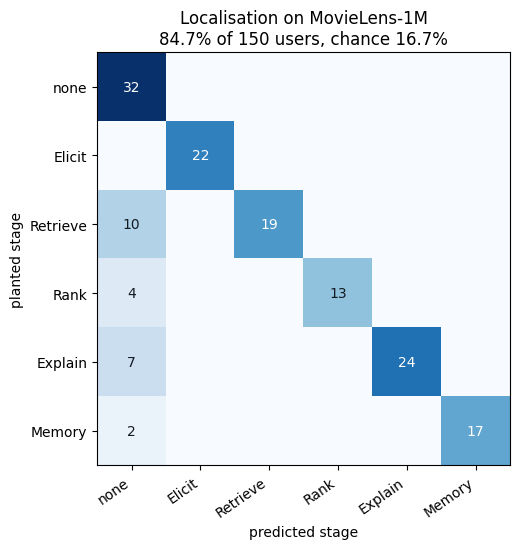

errors that name the WRONG stage: 0
errors that are missed detections (predicted 'none'): 23


In [15]:
#@title 13A. Does argmax D_A recover the planted stage?
labels = ["none"] + STAGES
cm = (pd.crosstab(LOC["true_stage"], LOC["predicted"])
      .reindex(index=labels, columns=labels, fill_value=0).fillna(0))
acc = (LOC["true_stage"] == LOC["predicted"]).mean()

fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = int(cm.values[i, j])
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=10,
                    color="white" if v > cm.values.max() / 2 else INK)
ax.set_xlabel("predicted stage"); ax.set_ylabel("planted stage")
ax.set_title(f"Localisation on MovieLens-1M\n{acc:.1%} of {len(LOC)} users, chance 16.7%")
plt.tight_layout(); plt.savefig(OUT / "ml1m_localisation_confusion.png", dpi=160, bbox_inches="tight")
plt.show()

wrong_stage = int(sum(cm.loc[t, p] for t in labels for p in labels if t != p and p != "none"))
missed = int(sum(cm.loc[t, "none"] for t in labels if t != "none"))
print(f"errors that name the WRONG stage: {wrong_stage}")
print(f"errors that are missed detections (predicted 'none'): {missed}")

Every error is a missed detection. No user's fault is attributed to the wrong stage, which is the failure mode that would make the estimator unusable.

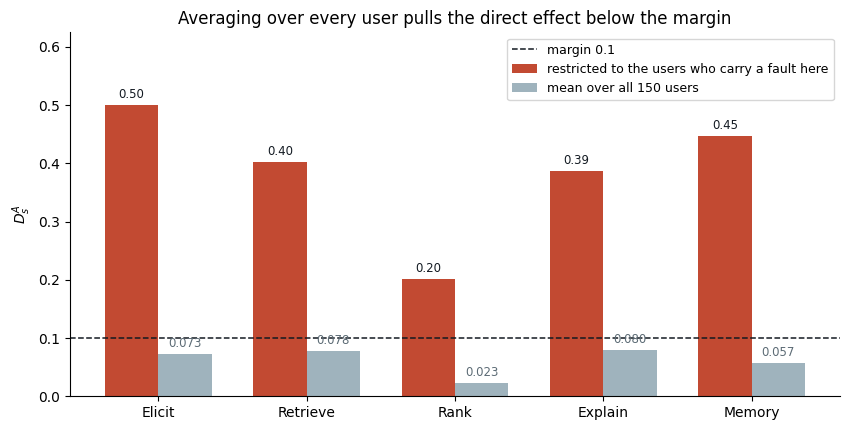

          planted users only  all users  clears margin alone?
stage                                                        
Elicit                0.5000     0.0733                 False
Retrieve              0.4027     0.0779                 False
Rank                  0.2010     0.0228                 False
Explain               0.3871     0.0800                 False
Memory                0.4474     0.0567                 False


In [16]:
#@title 13B. Why the per-stage average hides the signal
sens = RESULTS["sensitivity"].copy()
sens["is_planted"] = sens["stage"] == sens["planted_stage"]
planted = sens[sens["is_planted"]].groupby("stage")["direct"].mean().reindex(STAGES).fillna(0)
everyone = sens.groupby("stage")["direct"].mean().reindex(STAGES).fillna(0)

fig, ax = plt.subplots(figsize=(8.6, 4.4))
xs = np.arange(len(STAGES)); w = 0.36
ax.bar(xs - w / 2, planted.values, w, color=WARN,
       label="restricted to the users who carry a fault here")
ax.bar(xs + w / 2, everyone.values, w, color=SOFT,
       label="mean over all %d users" % len(SAMPLE))
ax.axhline(DIRECT_EFFECT_MARGIN, ls="--", lw=1.1, color=INK, label=f"margin {DIRECT_EFFECT_MARGIN}")
for x, v in zip(xs - w / 2, planted.values):
    ax.text(x, v + 0.012, f"{v:.2f}", ha="center", fontsize=8.5, color=INK)
for x, v in zip(xs + w / 2, everyone.values):
    ax.text(x, v + 0.012, f"{v:.3f}", ha="center", fontsize=8.5, color=MUTED)
ax.set_xticks(xs, STAGES); ax.set_ylabel("$D_s^A$")
ax.set_ylim(0, max(planted.max(), DIRECT_EFFECT_MARGIN) * 1.25)
ax.set_title("Averaging over every user pulls the direct effect below the margin")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(OUT / "ml1m_signal_vs_average.png", dpi=160, bbox_inches="tight")
plt.show()

cmp = pd.DataFrame({"planted users only": planted, "all users": everyone})
cmp["clears margin alone?"] = cmp["all users"] > DIRECT_EFFECT_MARGIN
print(cmp.round(4).to_string())


Restricted to the users who actually carry a fault at that stage, the direct effect clears the margin. Averaged over all 150 users it does not. The per-user argmax is the readout that works; the per-stage mean is not.

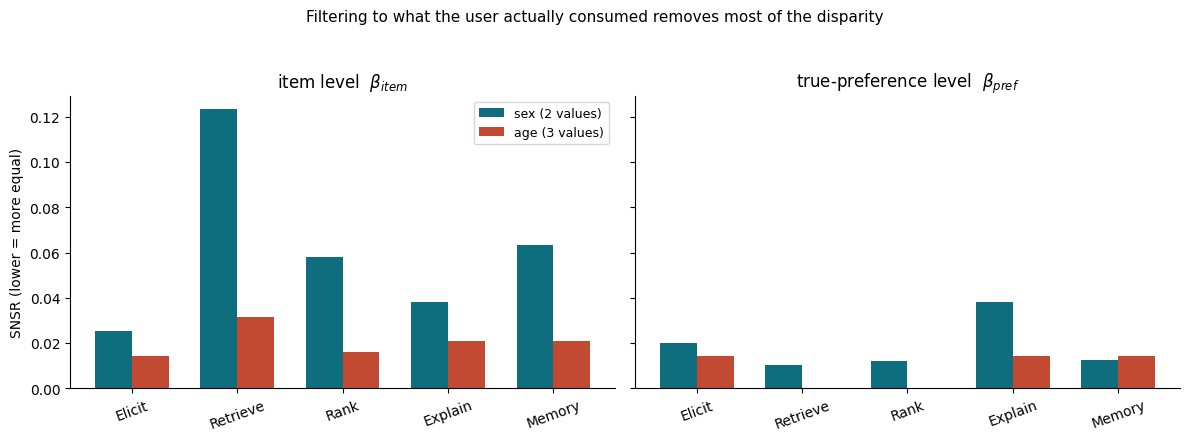

sim_item: mean SNSR 0.0412, max 0.1233, zero at 0 of 10 rows
sim_pref: mean SNSR 0.0135, max 0.0380, zero at 2 of 10 rows


In [17]:
#@title 13C. SNSR at both benefit levels
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, coord in zip(axes, ["sim_item", "sim_pref"]):
    sub = DISPERSION[DISPERSION["coordinate"] == coord]
    xs = np.arange(len(STAGES)); width = 0.35
    for off, attribute, color in zip([-width / 2, width / 2], ["sex", "age"], [KEY, WARN]):
        vals = [sub[(sub["attribute"] == attribute) & (sub["stage"] == s)]["SNSR"].mean()
                for s in STAGES]
        ax.bar(xs + off, vals, width, color=color,
               label=f"{attribute} ({len(ATTRIBUTES[attribute])} values)")
    ax.set_xticks(xs, STAGES, rotation=20)
    ax.set_title("item level  $\\beta_{item}$" if coord == "sim_item"
                 else "true-preference level  $\\beta_{pref}$")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("SNSR (lower = more equal)"); axes[0].legend(fontsize=9)
fig.suptitle("Filtering to what the user actually consumed removes most of the disparity",
             fontsize=11, y=1.04)
plt.tight_layout(); plt.savefig(OUT / "ml1m_snsr.png", dpi=160, bbox_inches="tight"); plt.show()

for coord in ["sim_item", "sim_pref"]:
    sub = DISPERSION[DISPERSION["coordinate"] == coord]
    print(f"{coord}: mean SNSR {sub['SNSR'].mean():.4f}, max {sub['SNSR'].max():.4f}, "
          f"zero at {int((sub['SNSR'] == 0).sum())} of {len(sub)} rows")

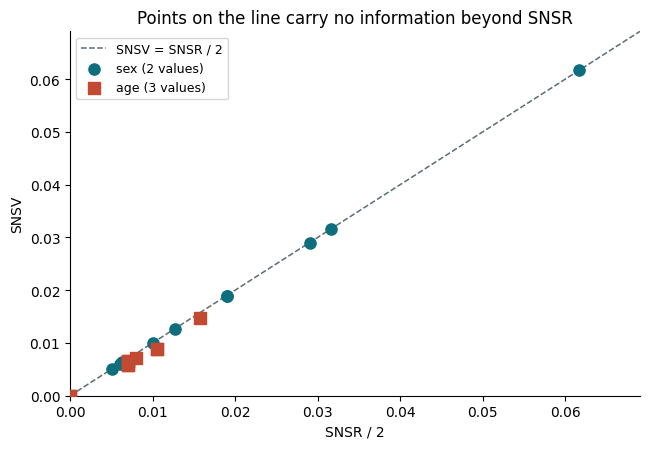

sex: identity holds on 10 of 10 rows
age: identity holds on 2 of 10 rows


In [18]:
#@title 13D. SNSV carries nothing new until the attribute has three values
fig, ax = plt.subplots(figsize=(6.6, 4.6))
hi = max(DISPERSION["SNSR_over_2"].max(), DISPERSION["SNSV"].max()) * 1.12
ax.plot([0, hi], [0, hi], ls="--", lw=1.1, color=MUTED, label="SNSV = SNSR / 2")
for attribute, color, marker in [("sex", KEY, "o"), ("age", WARN, "s")]:
    sub = DISPERSION[DISPERSION["attribute"] == attribute]
    ax.scatter(sub["SNSR_over_2"], sub["SNSV"], s=65, color=color, marker=marker, zorder=3,
               label=f"{attribute} ({len(ATTRIBUTES[attribute])} values)")
ax.set_xlabel("SNSR / 2"); ax.set_ylabel("SNSV")
ax.set_xlim(0, hi); ax.set_ylim(0, hi)
ax.set_title("Points on the line carry no information beyond SNSR")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(OUT / "ml1m_snsv_identity.png", dpi=160, bbox_inches="tight")
plt.show()

for attribute in ["sex", "age"]:
    sub = DISPERSION[DISPERSION["attribute"] == attribute]
    print(f"{attribute}: identity holds on {int(sub['identity_holds'].sum())} of {len(sub)} rows")

For a two-valued attribute the population standard deviation of two means is exactly half their range, so every `sex` point sits on the diagonal and SNSV adds nothing. The `age` points leave the line, which is the case that justifies reporting both.

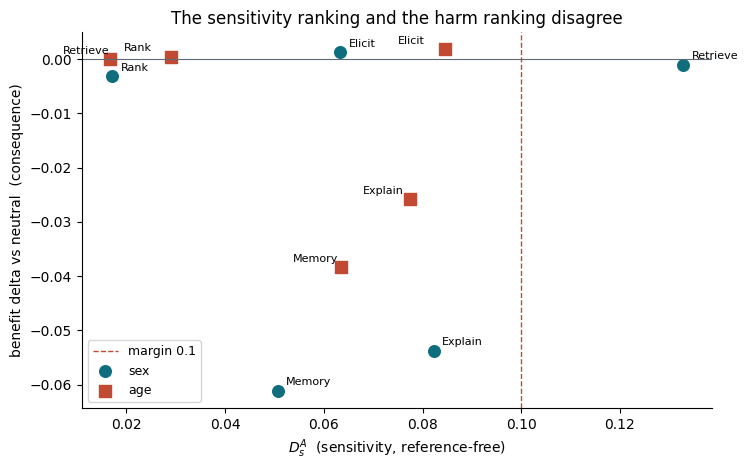

In [19]:
#@title 13E. Sensitivity against consequence
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.axhline(0, color=MUTED, lw=0.8)
ax.axvline(DIRECT_EFFECT_MARGIN, color=WARN, lw=1.0, ls="--",
           label=f"margin {DIRECT_EFFECT_MARGIN}")
for attribute, color, marker, dx in [("sex", KEY, "o", 6), ("age", WARN, "s", -34)]:
    sub = SIDE[SIDE["attribute"] == attribute]
    ax.scatter(sub["D_A"], sub["benefit_delta"], marker=marker, s=70, color=color, label=attribute)
    for _, r in sub.iterrows():
        ax.annotate(r["stage"], (r["D_A"], r["benefit_delta"]), fontsize=8,
                    xytext=(dx, 4), textcoords="offset points")
ax.set_xlabel("$D_s^A$  (sensitivity, reference-free)")
ax.set_ylabel("benefit delta vs neutral  (consequence)")
ax.set_title("The sensitivity ranking and the harm ranking disagree")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(OUT / "ml1m_sensitivity_vs_consequence.png", dpi=160,
                                bbox_inches="tight")
plt.show()

A stage high on the horizontal axis changed its output; a stage low on the vertical axis left the user worse off. The two orderings are not the same, which is the whole argument for keeping the reference beside $D_s^A$ rather than inside it.

In [20]:
#@title 13F. Export tables
for name, frame in RESULTS.items():
    frame.to_csv(OUT / f"{name}.csv", index=False)
DISPERSION.to_csv(OUT / "dispersion.csv", index=False)
SIDE.to_csv(OUT / "sensitivity_vs_consequence.csv", index=False)
BY_STRATEGY.to_csv(OUT / "snsr_by_strategy.csv", index=False)
(OUT / "run_manifest.json").write_text(json.dumps({
    "dataset": "MovieLens-1M", "n_users": len(SAMPLE), "top_k": TOP_K,
    "like_threshold": LIKE_THRESHOLD, "test_fraction": TEST_FRACTION,
    "age_buckets": {str(k): v for k, v in AGE_BUCKETS.items()},
    "sampling_strategies": SAMPLING_STRATEGIES, "repeats": N_REPEATS, "seed": SEED,
}, indent=2))
print("exported to", OUT.resolve())
for p in sorted(OUT.iterdir()):
    print("  -", p.name)

exported to /private/tmp/claude-501/-Users-jiarui-niw-github-fair-trace/0fe9f38e-f4de-48a4-8479-6c571e0e715d/scratchpad/ml1m_run/fair_trace_ml1m_outputs
  - consequence.csv
  - dispersion.csv
  - ml1m_localisation_confusion.png
  - ml1m_sensitivity_vs_consequence.png
  - ml1m_signal_vs_average.png
  - ml1m_snsr.png
  - ml1m_snsv_identity.png
  - run_manifest.json
  - sensitivity.csv
  - sensitivity_vs_consequence.csv
  - similarity.csv
  - snsr_by_strategy.csv


## 14. Reading the output

**What is real here.** The catalog, the ratings, the attributes, and above all the reference:
\(\mathcal{G}_s\) is built from films these users actually went on to rate highly. When a stage
scores a low benefit it means the agent failed *this user*, not a simulated one.

**What is still artificial.** The planted faults. They stay because they are how the instrument
is tested — without a known answer there is nothing to check localisation against. The
stereotype table (`BIAS_GENRE`) is a measurement device, not a claim about what any group likes.

**Known limitations, unchanged from the toy run.**

- No noise floor yet. The stage functions are deterministic, so repeats agree exactly here;
  the moment a served model replaces them, every number needs a rerun spread beside it.
- SNSR averages over users before taking the range, so it measures *systematic* group-level
  asymmetry and is close to blind to per-user faults that alternate direction. It complements
  \(D_s^A\); it cannot replace it.
- Benefit at Explain and Memory is a precision, so it is undefined when a stage emits nothing.
  Those cells are NaN and drop out of the means.
- The era and genre abstraction is coarse. A user whose taste is "Drama, recent" is a thin
  description of a real person.